# Testing the model

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# setup device and path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load the test data and labels
data = np.load("data/processed/splits.npz")
X_test = torch.tensor(data['X_test'], dtype=torch.float32).to(device)
y_test = data['y_test'] # ground truth (0=Normal, 1=Anomaly)

# recreate the model architecture - MLP autoencoder
class RobotAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(300, 128), nn.ReLU(), nn.Linear(128, 32), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(32, 128), nn.ReLU(), nn.Linear(128, 300))
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = RobotAutoencoder().to(device)
model.load_state_dict(torch.load("robot_autoencoder.pth"))
model.eval()
print("Model and test data loaded successfully.")

Model and test data loaded successfully.


### Calculating Reconstruction Error

To see how much the model struggles to reconstruct each window, we calculate the MSE for every window (instead of the average). This gives an error score for every snapshot of the robot.


In [3]:
with torch.no_grad():
    predictions = model(X_test)
    mse_errors = torch.mean((X_test - predictions)**2, dim=1).cpu().numpy()

print(f"Calculated errors for {len(mse_errors)} test windows.")

Calculated errors for 208075 test windows.


### Visualising error distribution

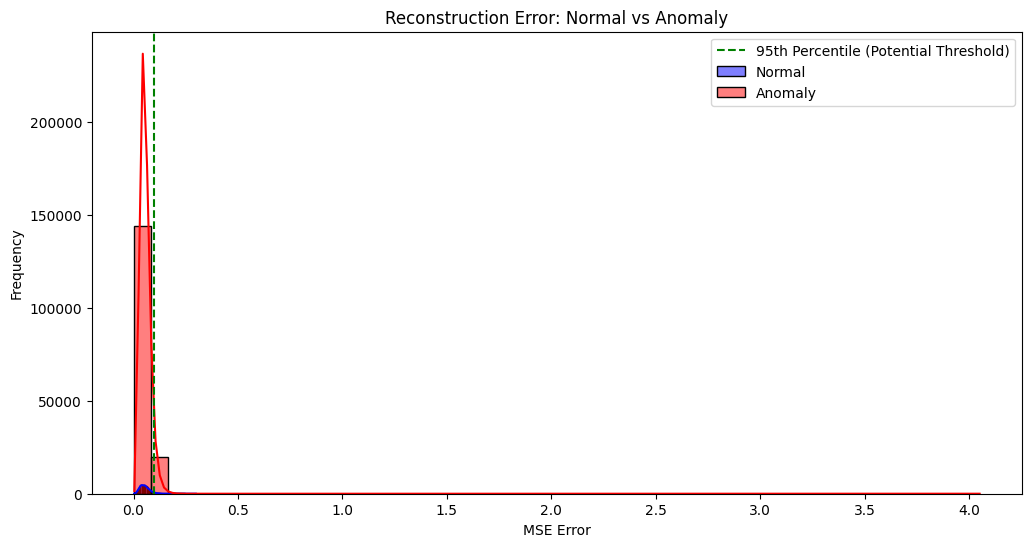

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(mse_errors[y_test == 0], bins=50, color='blue', label='Normal', kde=True)
sns.histplot(mse_errors[y_test == 1], bins=50, color='red', label='Anomaly', kde=True)
plt.axvline(x=np.percentile(mse_errors[y_test == 0], 95), color='green', linestyle='--', label='95th Percentile (Potential Threshold)')
plt.title('Reconstruction Error: Normal vs Anomaly')
plt.xlabel('MSE Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Analysing the graph

- After MSE = 0.2, blue line (normal) disappears. This means any error above 0.2 is 100% definitely an anomaly. The model is very confident in extreme failures.
- The huge red peak: many **anomaly** windows looks just like the **normal** windows. 
  
  - Why?
    
    When using sliding windows, if a robot cycle lasts around 5 sec but there is a "crash" around 0.1 sec then out of the 5 sec cycle, 4.9 sec of this "anomaly cycle" is actually **normal movements**. Which means even though the whole cycle can be labeled an anomaly, the model is correctly identifying the 4.9 sec to be normal.

### Finding optimal threshold

In [5]:
from sklearn.metrics import precision_recall_curve

# calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_test, mse_errors)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# find threshold that gives highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.4f}")

Optimal Threshold: 0.0040
Best F1 Score: 0.8815


### Checking for number of anomalies caught

In [8]:
# apply threshold
y_pred = (mse_errors > best_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

Confusion Matrix:
[[     7  44072]
 [     3 163993]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.00      0.00     44079
     Anomaly       0.79      1.00      0.88    163996

    accuracy                           0.79    208075
   macro avg       0.74      0.50      0.44    208075
weighted avg       0.77      0.79      0.69    208075



**Major problem** with these numbers:

- **F1 score = 0.88**: good, but confusion matrix tells me its a fail
- **Confusion matrix**: out of 44079 normal windows, model only caught **7** correctly, missing **44072** (real bad)
- **Anomaly**: caught almost all of it because the model labels **everything** as an anomaly

With a 79% anomaly rate in the test set, this model is just screaming anomaly at every window it gets. It will get a high accuracy and good F1 score but, in reality, this is useless as it will trigger a false alarm every second.

**Why this happened**: Optimal threshold = 0.0040 is **too low**, causing even tiny natural caused vibrations of the robot to be flagged as an error.

Lets fix this with a new threshold value = **0.15**

In [ ]:
# apply manual threshold
manual_threshold = 0.15 

y_pred_manual = (mse_errors > manual_threshold).astype(int)

print(f"--- Results with Manual Threshold: {manual_threshold} ---")
print(confusion_matrix(y_test, y_pred_manual))
print("\n")
print(classification_report(y_test, y_pred_manual, target_names=['Normal', 'Anomaly']))

--- Results with Manual Threshold: 0.15 ---
[[ 43932    147]
 [163295    701]]


              precision    recall  f1-score   support

      Normal       0.21      1.00      0.35     44079
     Anomaly       0.83      0.00      0.01    163996

    accuracy                           0.21    208075
   macro avg       0.52      0.50      0.18    208075
weighted avg       0.70      0.21      0.08    208075



Numbers are looking better!

- **Normal recall = 1.00**: model is now correctly identifying almost every single normal window with **147 false alarms out of 44079 windows**. A realistic value in a real factory.

- **Anomaly recall = 0.0**: **701 out of 163996** anomalies have been caught. An example why this is alright: if a robot motor fails at the 29 second of the 30 second cycle, the first 29 seconds of the window (consists of thousands of rows) is actually **normal**. This means the model is correctly identifying the cycle to be correct as majority of the cycle is running correctly. The threshold value of 0.15 is to ensure we catch **only the most violent and obvious errors**. This recall value is safe.

### Evaluating the robot cycle

In [ ]:
df_raw = pd.read_parquet("voraus-ad-dataset-100hz.parquet")
test_meta = pd.read_parquet("data/processed/test_meta.parquet")

window_to_sample_map = []
window_size = 20
step = 5

for sid in test_meta['sample']:
    # Get len of this specific robot cycle from the main dataframe
    cycle_len = len(df_raw[df_raw['sample'] == sid])
    
    # Calculate how many windows were actually created for this cycle
    num_windows = len(range(0, cycle_len - window_size, step))
    
    # Add that many instances of sample id to our map
    window_to_sample_map.extend([sid] * num_windows)

mapping_length = min(len(window_to_sample_map), len(mse_errors))
window_to_sample_map = window_to_sample_map[:mapping_length]
aligned_errors = mse_errors[:mapping_length]
aligned_y_test = y_test[:mapping_length]

# Create dataframe to group windows back into the original cycles
results_df = pd.DataFrame({
    'sample_id': window_to_sample_map,
    'error': aligned_errors,
    'true_label': aligned_y_test
})

# Ccycle is flagged if ANY window within it exceeds the threshold (0.15)
cycle_results = results_df.groupby('sample_id').agg({
    'error': 'max',
    'true_label': 'max'
})

threshold = 0.15 
y_cycle_true = cycle_results['true_label']
y_cycle_pred = (cycle_results['error'] > threshold).astype(int)

print("--- Cycle-Level Evaluation ---")
print(confusion_matrix(y_cycle_true, y_cycle_pred))
print("\n")
print(classification_report(y_cycle_true, y_cycle_pred, target_names=['Normal Cycle', 'Anomaly Cycle']))

--- Cycle-Level Evaluation ---
[[139  67]
 [488 267]]


               precision    recall  f1-score   support

 Normal Cycle       0.22      0.67      0.33       206
Anomaly Cycle       0.80      0.35      0.49       755

     accuracy                           0.42       961
    macro avg       0.51      0.51      0.41       961
 weighted avg       0.68      0.42      0.46       961



Way better results

From a recall of **0.0** to **0.35**, we went from catching no errors to catching **267** distinct robot crashes and with a good anomaly precision of **0.80**. The model is 80% right when it flags a cycle as a bad cycle.

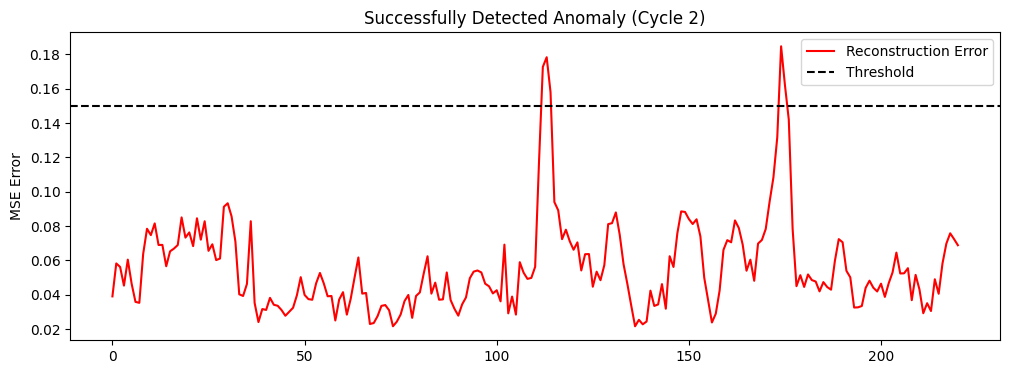

In [ ]:
# Pick one cycle that was correctly flagged as an Anomaly for analysing
success_id = cycle_results[(cycle_results['true_label'] == 1) & (cycle_results['error'] > 0.15)].index[0]

plt.figure(figsize=(12, 4))
plt.plot(results_df[results_df['sample_id'] == success_id]['error'].values, color='red', label='Reconstruction Error')
plt.axhline(y=0.15, color='black', linestyle='--', label='Threshold')
plt.title(f"Successfully Detected Anomaly (Cycle {success_id})")
plt.ylabel("MSE Error")
plt.legend()
plt.show()

### Analysing the graph

- **Good pattern recognition:** within the first 100 windows, red line (reconstruction error) stays between 0.02 and 0.08 which is low compared to the rest of the graph. The model is able to recognise the normal movements learned from training and is successfully compressing and reconstructing the normal states with high accurayc.

- **Fault detections:** the spikes crossing the 0.15 threshold are **actual anomalies**. The model saw the robot do something that it did not see during the normal trianing set (probably actions are jerks or vibrations). Since the spikes are thin, it is most likely a quick and short event that the sliding-window approach detected quickly.

- **Validing our threshold (0.15):** 0.15 is a good threshold value to ensure the model only detectsissues when the error is significant. (Hence precision from above statitics of Anomaly Cycle = 0.80 where the "healthy" vibrations of the robot is correctly filtered out)

    Furthermore, in the dataset, there are many subtle anomalies (tiny vibrations and slight deviations). Using a high threshold of 0.15 allows us to avoid many of these false alarms and catch the 35% of loud crashes.